# Calibration Testing Plots
## Currently separate cells for calibration node vs OG node because different file formats
## i.e calibration node is in regular format ZE.C2516..GPZ_YYYYMMDD whereas OG node is still in drive format
### -- need to either convert drive data to typical format OR adjust scripts to read drive format properly --

## NOTE TO SELF:
### need to automate to extract network/stas/etc more efficiently
### reduce manual inputs for each run
### e.g adjust so i don't have to change: calib/reg_node file path, calib/reg_node figure save path, figure names, time range, wave/spectra plot names, if interval folder names for each run/station

In [1]:
import obspy
from obspy import read, UTCDateTime
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import numpy as np
import os
from matplotlib.ticker import MultipleLocator

C:\Users\zzawol\AppData\Local\miniforge3\envs\obspyenv\Lib\site-packages\obspy\core\util\base.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Calibration Node for Calibration Testing Plots
### zoomed in time window

Sampling rate: 1000.0 Hz
Number of samples: 60001
Plotting and saving raw waveform...
Time range for plot: 0.0 to 60.001 seconds
Time range for plot: 0.0 to 60.001 seconds
Saving waveform to: C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2512\C2512_rock_wave.png


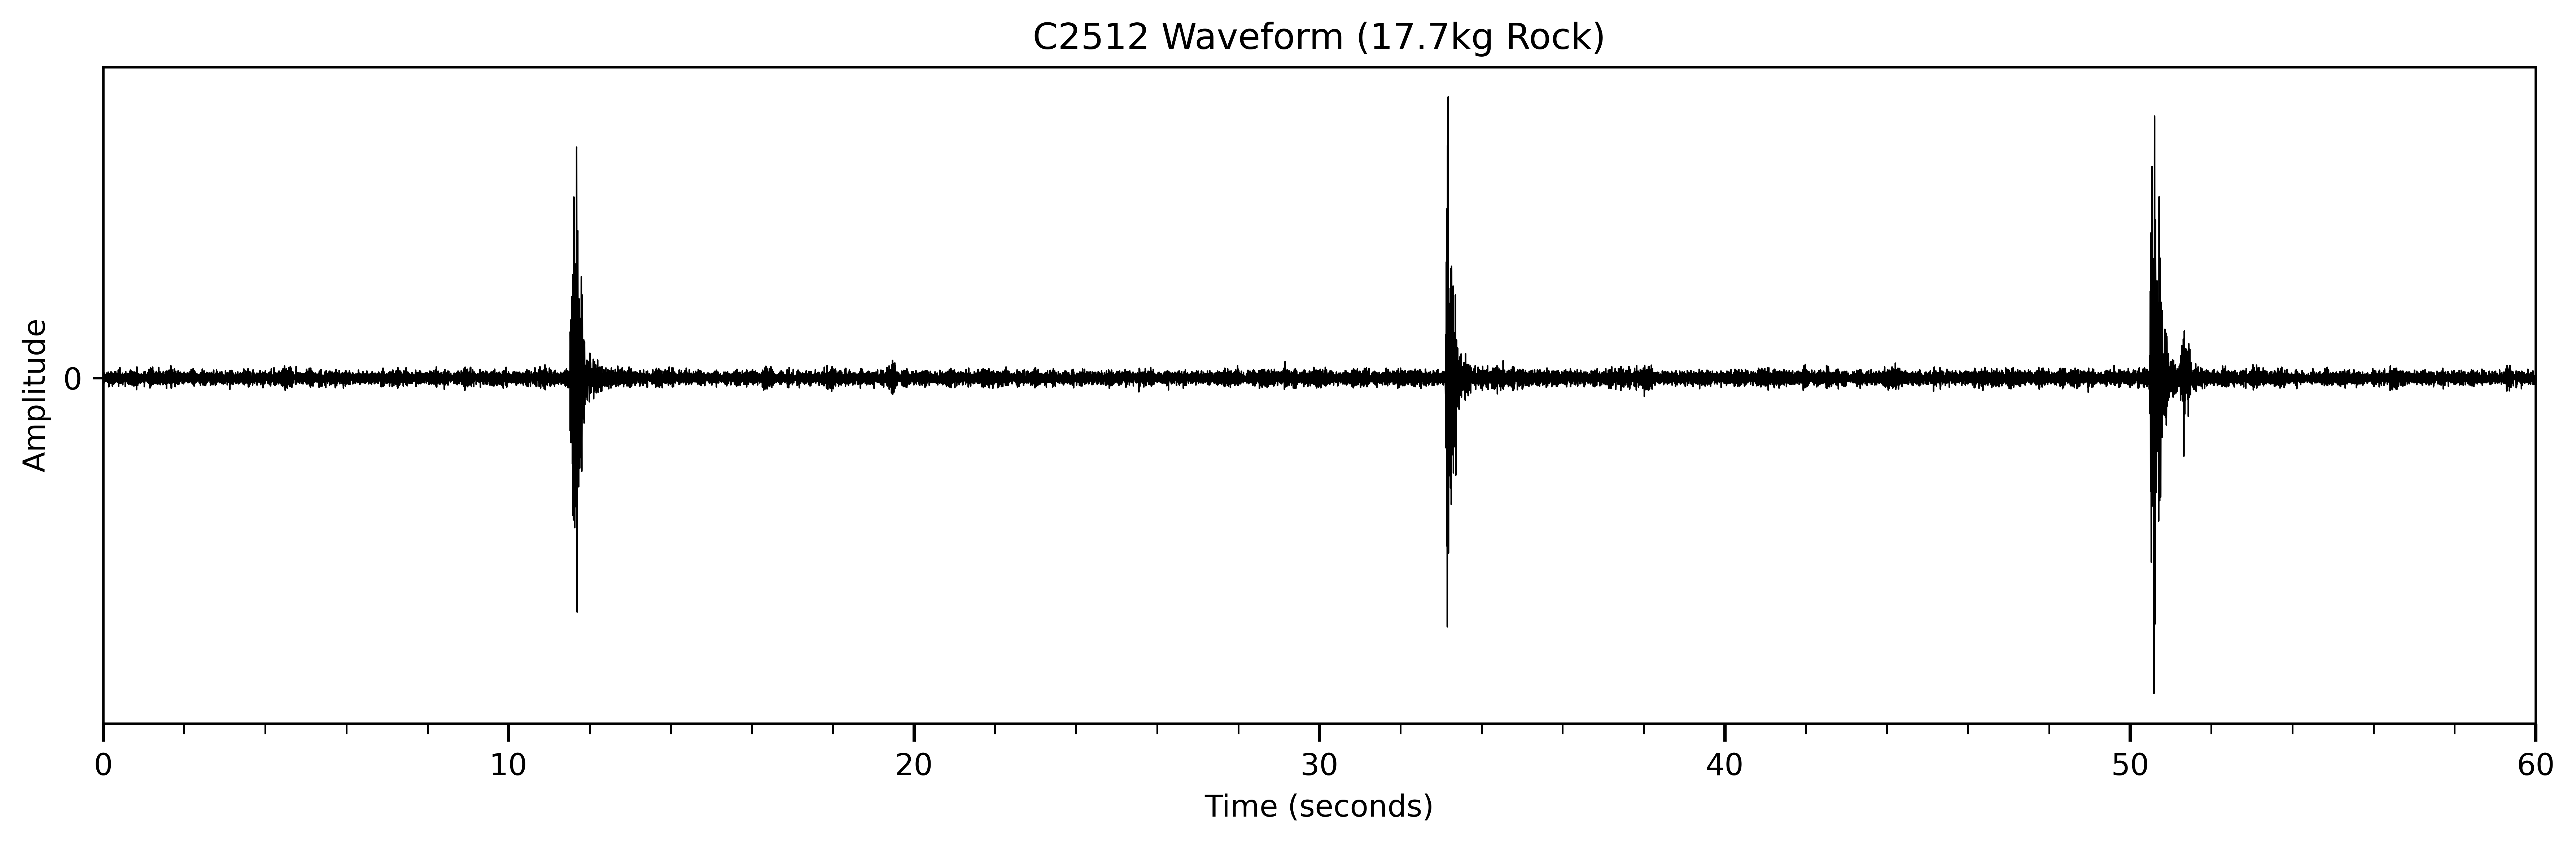

Computing and saving spectrogram...
Saving spectrogram to: C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2512\C2512_rock_spectra.png


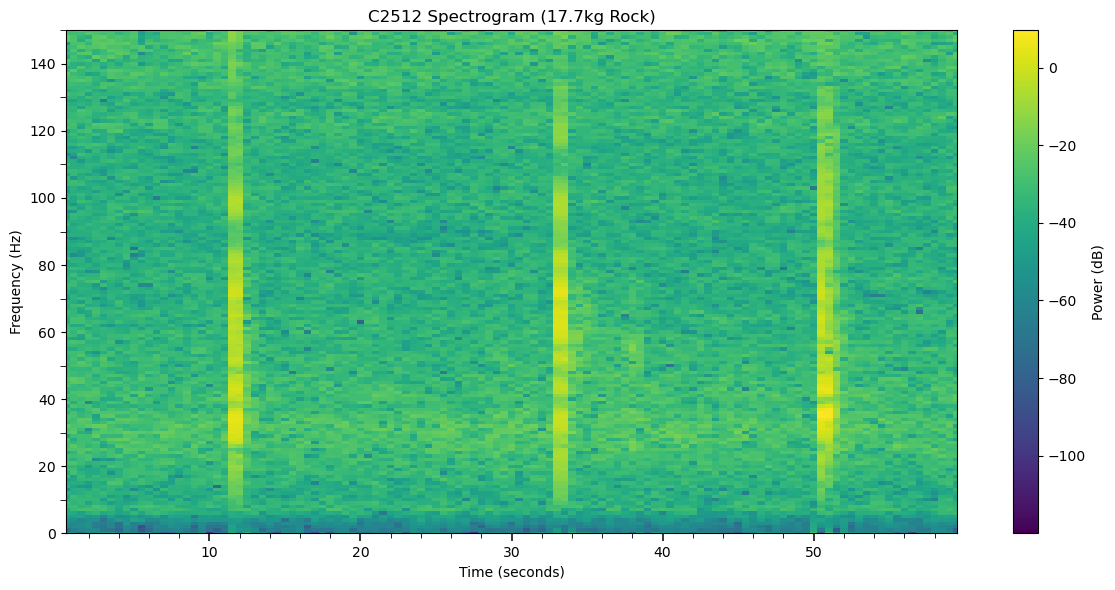

In [2]:
### cell for plotting calibration node data ###

calib_file = r"D:/calibration_rename_test/NOC2512/GPZ/ZE.C2512..GPZ_*.mseed"
start_time = UTCDateTime(2025, 10, 24, 00, 20, 55) # N12 rock
end_time = UTCDateTime(2025, 10, 24, 00, 21, 55)

SC = read(calib_file)#, starttime=start_time, endtime=end_time)
SC.merge(method=1)
SC.trim(starttime=start_time, endtime=end_time)

trC = SC[0]

print(f"Sampling rate: {trC.stats.sampling_rate} Hz")
print(f"Number of samples: {len(trC.data)}")

# ----------------------------------------------------- raw waveform ----------------------------------------------------------

print("Plotting and saving raw waveform...")

time = np.linspace(0, len(trC.data)/trC.stats.sampling_rate, len(trC.data)) #+ offset_seconds
print(f"Time range for plot: {time[0]} to {time[-1]} seconds")
print(f"Time range for plot: {np.min(time)} to {np.max(time)} seconds")


# plot raw waveform
fig, ax = plt.subplots(figsize=(12,4), dpi=600)

ax.plot(time, trC.data, color='black', lw=0.5)

# ticks
ax.xaxis.set_major_locator(MultipleLocator(10)) # labled every 10s
ax.xaxis.set_minor_locator(MultipleLocator(2)) # unlabled every 2s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(500)) # labeled every 500
ax.set_xlim(np.min(time), np.max(time))
ax.set_title("C2512 Waveform (17.7kg Rock)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
fig.tight_layout()

# define directory and png filename
plot_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2512" # find way to denote first 2 impacts as folder and/or png
plot_name = "C2512_rock_wave.png"

# directory exists
os.makedirs(plot_dir, exist_ok=True)

# full path for saving png
save_path = os.path.join(plot_dir, plot_name)

# save plot as png with high resolution
print("Saving waveform to:", save_path)
plt.savefig(save_path, format='png', dpi=600, bbox_inches='tight')

# save as png
fig.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)

# ----------------------------------------------------- spectrogram -----------------------------------------------------------

print("Computing and saving spectrogram...")

fs = trC.stats.sampling_rate

# window sizes (SAFE starting values)
nperseg = int(1 * fs)     # 10 ms window
noverlap = int(0.5 * fs)   # 50% overlap
# freq_resolution = df = fs / nperseg = 1000/10 = 100 hz bins

f, t, SCxx = spectrogram(
    trC.data,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    #outfile=savepath
)
fig, ax = plt.subplots(figsize=(12,6))

pcm = ax.pcolormesh(t, f, 10*np.log10(SCxx + 1e-12), cmap='viridis')

# ticks
ax.xaxis.set_major_locator(MultipleLocator(10)) # tick label every 10s
ax.xaxis.set_minor_locator(MultipleLocator(2)) # tick unlabeled every 2s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(20)) # tick label every 20 Hz
ax.yaxis.set_minor_locator(MultipleLocator(10)) # tick unlabeled every 10 Hz
ax.tick_params(axis='y', which='minor', length=4)
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (seconds)')
ax.set_ylim(0, 150)
ax.set_xlim(np.min(t), np.max(t))
ax.set_title("C2512 Spectrogram (17.7kg Rock)")
fig.colorbar(pcm, ax=ax, label='Power (dB)')
fig.tight_layout()

# define directory and png filename
spectra_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2512"
spectra_name = "C2512_rock_spectra.png"

# directory exists
os.makedirs(spectra_dir, exist_ok=True)

# full path for saving png
savepath = os.path.join(spectra_dir, spectra_name)

# save as png
print("Saving spectrogram to:", savepath)
fig.savefig(savepath, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)


## Original Node Calibration Testing Plots
### zoomed in time window

Loading data...
Sampling rate: 1000.0 Hz
Number of samples: 60001
Plotting and saving raw waveform
Saving waveform to: C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\og_node\NO2512\2512_rock_wave.png


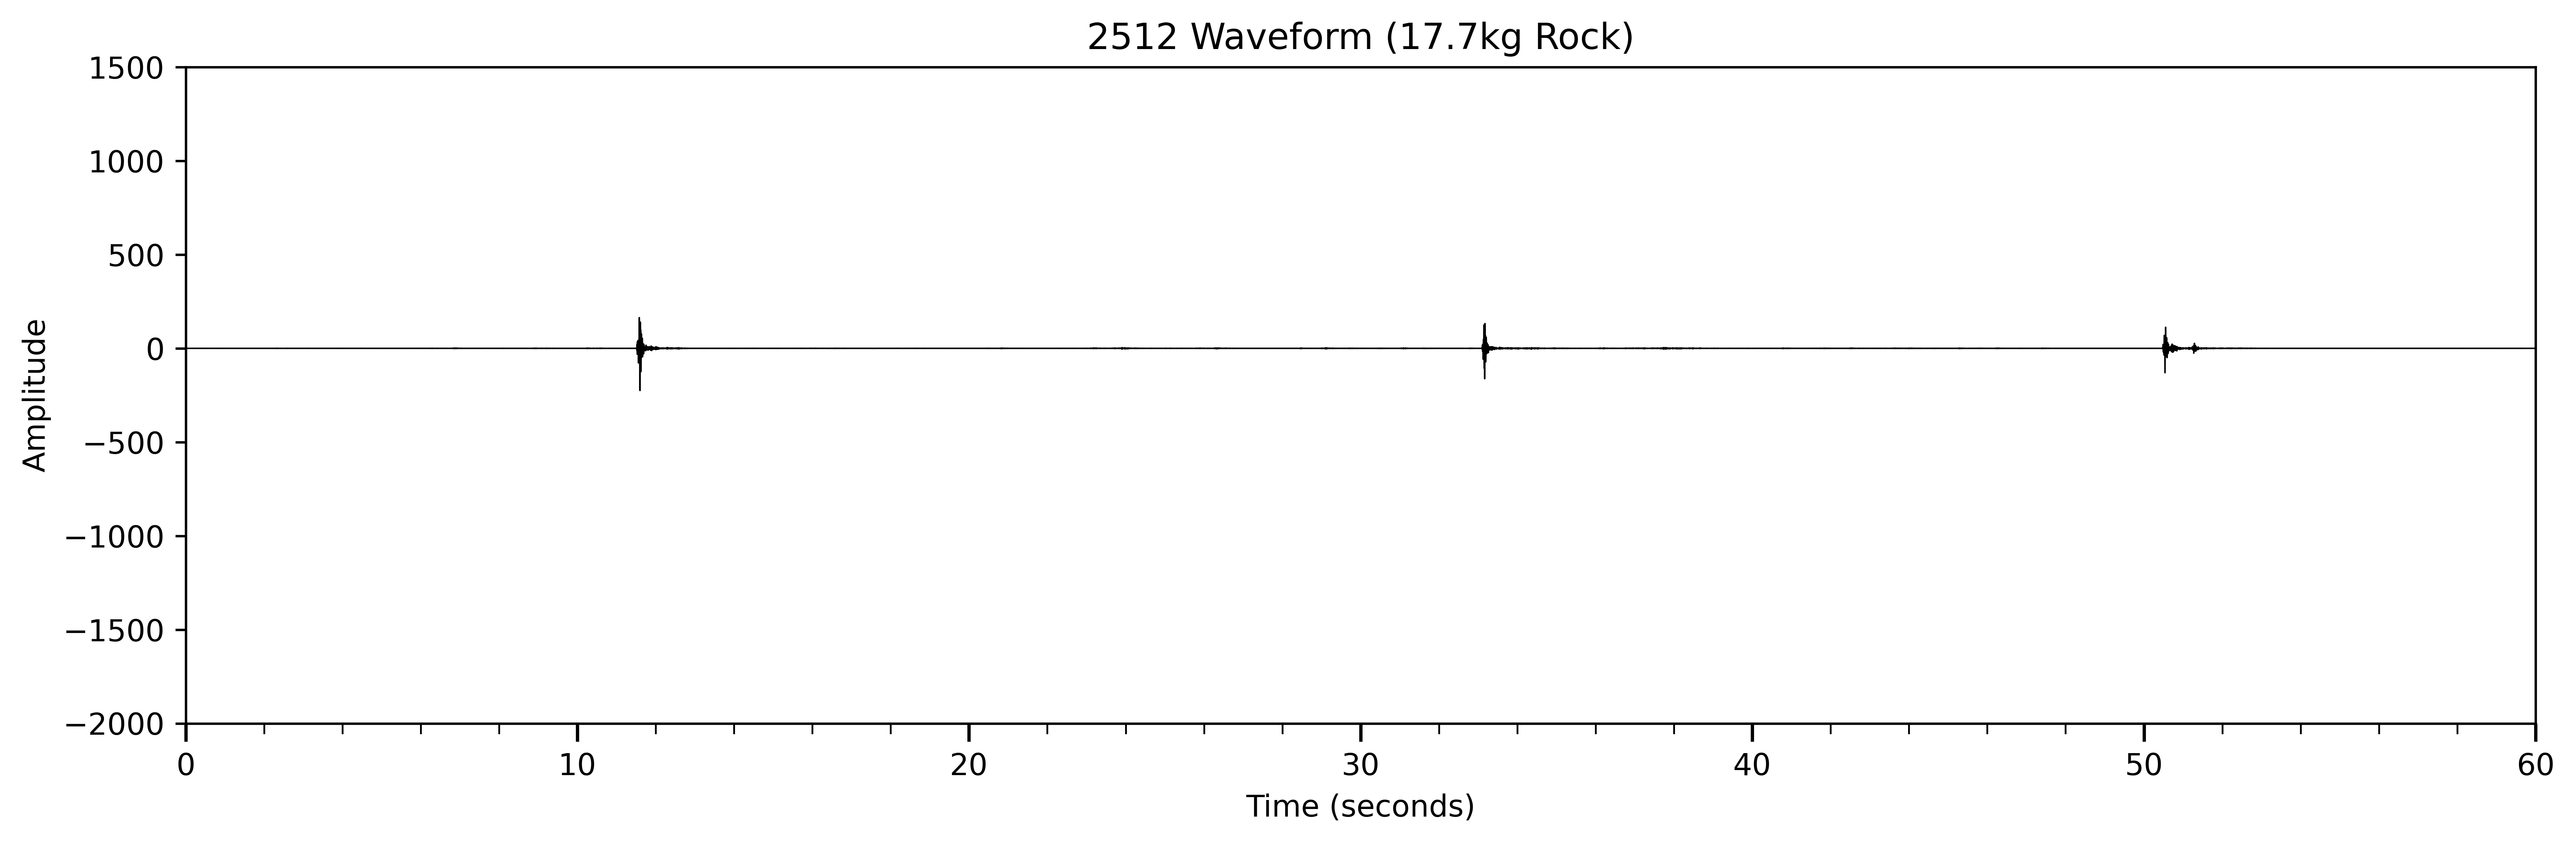

Computing and saving spectrogram...
Saving spectrogram to: C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\og_node\NO2512\2512_rock_spectra.png


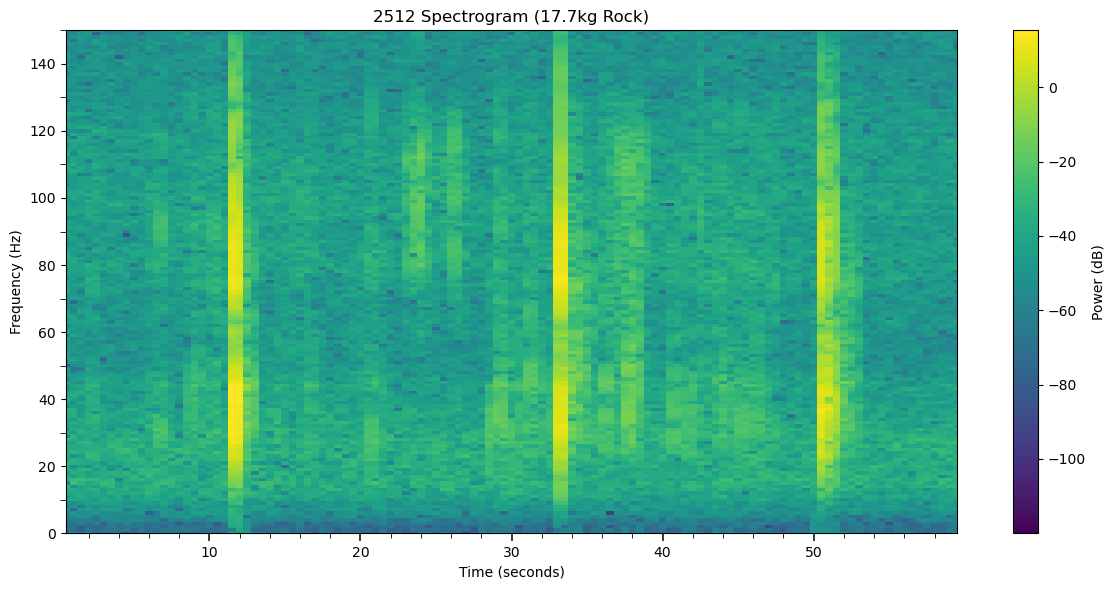

window length (ms): 1000, overlap (%): 500/1000 = 0.5


In [3]:
## notice different file format
node_file = r"D:\2025_MSEED_From_Nodes\453005768.*.2025.10.2*.Z.miniseed" #N12

start_time = UTCDateTime(2025, 10, 24, 00, 20, 55) # N12 rock
end_time = UTCDateTime(2025, 10, 24, 00, 21, 55)

print("Loading data...")
S = read(node_file)

# merge in case multiple files
S.merge(method=1)
S.trim(starttime=start_time, endtime=end_time)

tr = S[0]

print(f"Sampling rate: {tr.stats.sampling_rate} Hz")
print(f"Number of samples: {len(tr.data)}")

# ----------------------------------------------------- raw waveform ----------------------------------------------------------

print("Plotting and saving raw waveform")

time = np.linspace(0, len(tr.data)/tr.stats.sampling_rate, len(tr.data))# + offset_seconds

fig, ax = plt.subplots(figsize=(12,4), dpi=600)

ax.plot(time, tr.data, color='black', lw=0.5)

# ticks
ax.xaxis.set_major_locator(MultipleLocator(10)) # labled every 10s
ax.xaxis.set_minor_locator(MultipleLocator(2)) # unlabled every 2s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(500)) # labeled every 500
ax.set_ylim(-2000, 1500)
ax.set_xlim(np.min(time), np.max(time))
ax.set_title("2512 Waveform (17.7kg Rock)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
fig.tight_layout()

# define directory and png filename
plot_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\og_node\NO2512"
plot_name = "2512_rock_wave.png"

# directory exists
os.makedirs(plot_dir, exist_ok=True)

# full path for saving png
save_path = os.path.join(plot_dir, plot_name)

# save plot as png with high resolution
print("Saving waveform to:", save_path)
plt.savefig(save_path, format='png', dpi=600, bbox_inches='tight')

# save as png
fig.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)

# ----------------------------------------------------- spectrogram -----------------------------------------------------------

print("Computing and saving spectrogram...")

fs = tr.stats.sampling_rate

# window sizes (SAFE starting values)
nperseg = int(1 * fs)     # 10 ms window
noverlap = int(0.5 * fs)   # 50% overlap
# freq_resolution = df = fs / nperseg = 1000/10 = 100 hz bins

f, t, Sxx = spectrogram(
    tr.data,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    #outfile=savepath
)

fig, ax = plt.subplots(figsize=(12,6))

pcm = ax.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), cmap='viridis') #, vmin a= -100, vmax = 0)    ###### scale colorbar values! #####

# ticks
ax.xaxis.set_major_locator(MultipleLocator(10)) # tick label every 10s
ax.xaxis.set_minor_locator(MultipleLocator(2)) # tick unlabeled every 2s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(20)) # tick label every 20 Hz
ax.yaxis.set_minor_locator(MultipleLocator(10)) # tick unlabeled every 10 Hz
ax.tick_params(axis='y', which='minor', length=4)

ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (seconds)')
ax.set_ylim(0, 150)
ax.set_xlim(np.min(t), np.max(t))
ax.set_title("2512 Spectrogram (17.7kg Rock)")
fig.colorbar(pcm, ax=ax, label='Power (dB)')
fig.tight_layout()

# define directory and png filename
spectra_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\og_node\NO2512"
spectra_name = "2512_rock_spectra.png"

# directory exists
os.makedirs(spectra_dir, exist_ok=True)

# full path for saving png
savepath = os.path.join(spectra_dir, spectra_name)

# save as png
print("Saving spectrogram to:", savepath)
fig.savefig(savepath, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)

print(f"window length (ms): {nperseg}, overlap (%): {noverlap}/{nperseg} = {noverlap/nperseg}")



# Entire Calibration Testing Period - Calibration Node

1 Trace(s) in Stream:
SS.05764.SW.GPZ | 2025-09-18T20:29:09.000000Z - 2025-09-18T20:46:58.000000Z | 1000.0 Hz, 1069001 samples
Number of traces: 1
Sampling rate: 1000.0 Hz
Number of samples: 1069001
Plotting and saving raw waveform...
Saving waveform to: C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2503\full_wave\C2503_full_wave_2.png


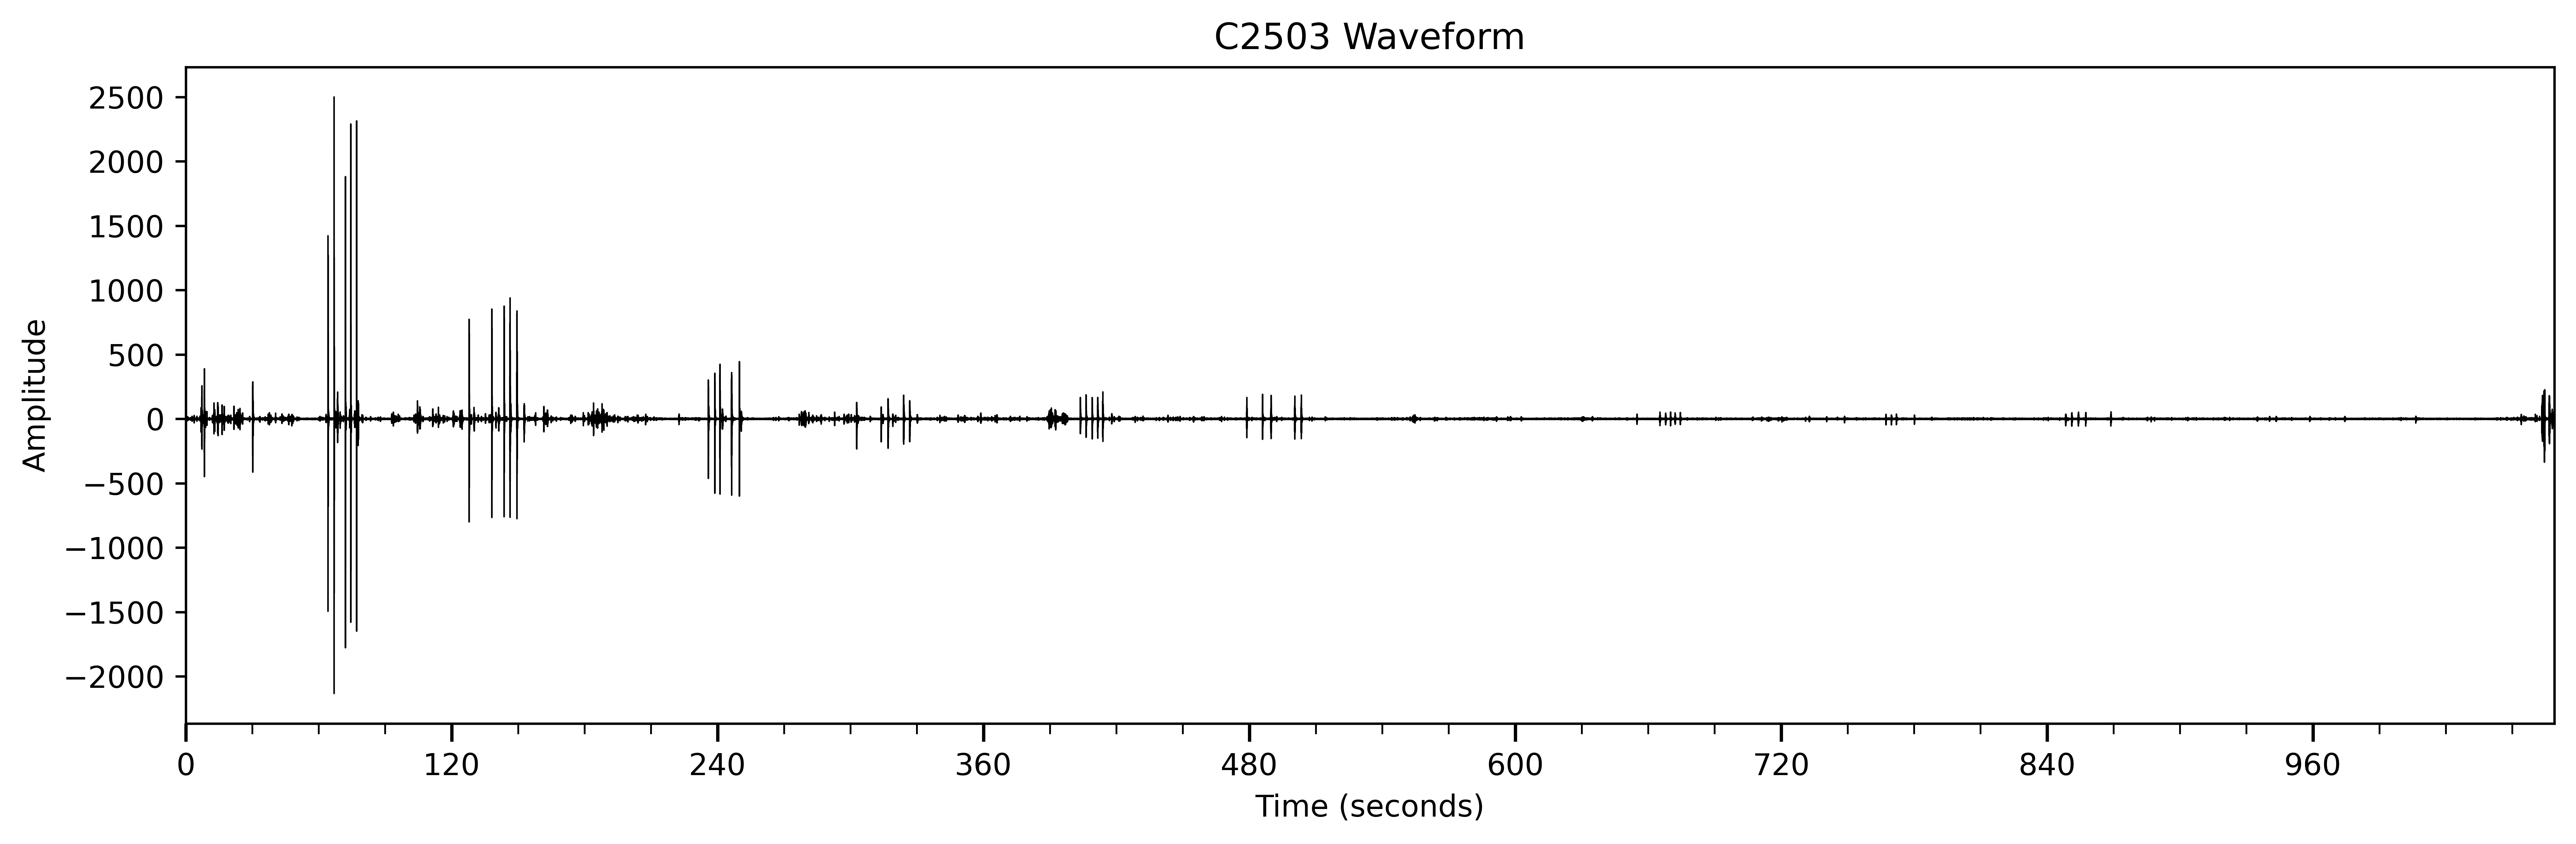

Computing and saving spectrogram...
Saving spectrogram to: C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2503\full_spectra\C2503_full_spectra_2.png


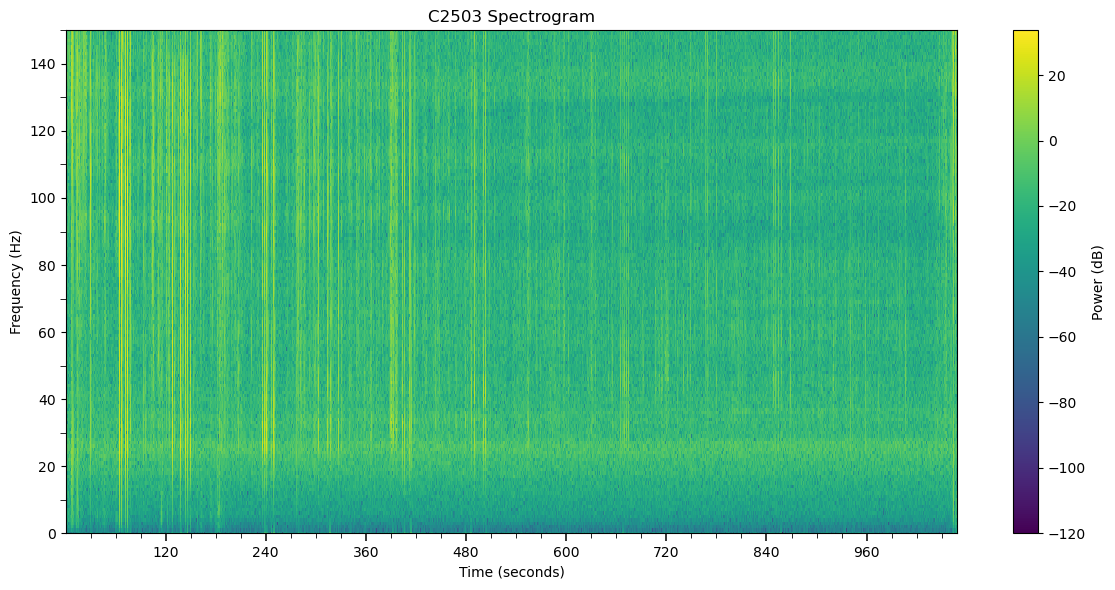

In [4]:
calib_file = r"D:/calibration_rename_test/NOC2503/GPZ/ZE.C2503..GPZ*.mseed"

start_time = UTCDateTime(2025, 9, 18, 20, 29)
end_time   = UTCDateTime(2025, 9, 18, 20, 44, 46)

SC = read(calib_file)#, starttime=start_time, endtime=end_time)

# merge in case multiple files
SC.merge(method=1)

print(SC)
print("Number of traces:", len(SC))
trC = SC[0]

print(f"Sampling rate: {trC.stats.sampling_rate} Hz")
print(f"Number of samples: {len(trC.data)}")

# ----------------------------------------------------- raw waveform ----------------------------------------------------------

print("Plotting and saving raw waveform...")

time = np.linspace(0, len(trC.data)/trC.stats.sampling_rate, len(trC.data))

fig, ax = plt.subplots(figsize=(12,4), dpi=600)

ax.plot(time, trC.data, color='black', lw=0.5)

# ticks
ax.xaxis.set_major_locator(MultipleLocator(120)) # labled every 10s
ax.xaxis.set_minor_locator(MultipleLocator(30)) # unlabled every 2s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(500)) # labeled every 500
ax.set_xlim(np.min(time), np.max(time))
ax.set_title("C2503 Waveform")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
fig.tight_layout()

# define directory and png filename
plot_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2503\full_wave"
plot_name = "C2503_full_wave_2.png"

# directory exists
os.makedirs(plot_dir, exist_ok=True)

# full path for saving png
save_path = os.path.join(plot_dir, plot_name)

# save plot as png with high resolution
print("Saving waveform to:", save_path)
plt.savefig(save_path, format='png', dpi=600, bbox_inches='tight')

# save as png
fig.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)

# ----------------------------------------------------- spectrogram -----------------------------------------------------------

print("Computing and saving spectrogram...")

fs = trC.stats.sampling_rate

# window sizes
nperseg = int(1 * fs)     # 10 ms window
noverlap = int(0.5 * fs)   # 50% overlap
# freq_resolution = df = fs / nperseg = 1000/10 = 100 hz bins

f, t, SCxx = spectrogram(
    trC.data,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    #outfile=savepath
)

fig, ax = plt.subplots(figsize=(12,6))

pcm = ax.pcolormesh(t, f, 10*np.log10(SCxx + 1e-12), cmap='viridis')

# ticks
ax.xaxis.set_major_locator(MultipleLocator(120)) # tick label every 10s
ax.xaxis.set_minor_locator(MultipleLocator(30)) # tick unlabeled every 2s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(20)) # tick label every 20 Hz
ax.yaxis.set_minor_locator(MultipleLocator(10)) # tick unlabeled every 10 Hz
ax.tick_params(axis='y', which='minor', length=4)

ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (seconds)')
ax.set_ylim(0, 150)
ax.set_xlim(np.min(t), np.max(t))
ax.set_title("C2503 Spectrogram")
fig.colorbar(pcm, ax=ax, label='Power (dB)')
fig.tight_layout()

# define directory and png filename
spectra_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\calib_node\C2503\full_spectra"
spectra_name = "C2503_full_spectra_2.png"

# directory exists
os.makedirs(spectra_dir, exist_ok=True)

# full path for saving png
savepath = os.path.join(spectra_dir, spectra_name)

# save as png
print("Saving spectrogram to:", savepath)
fig.savefig(savepath, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)

# Entire Calibration Testing Period - OG Node

Trace range: 2025-10-20T00:00:00.000000Z → 2025-10-21T00:00:00.000000Z
File being read: D:\2025_MSEED_From_Nodes\453005768.*.2025.10.2*.Z.miniseed
11 Trace(s) in Stream:
SS.05768.SW.GPZ | 2025-10-20T00:00:00.000000Z - 2025-10-21T00:00:00.000000Z | 1000.0 Hz, 86400001 samples
SS.05768.SW.GPZ | 2025-10-21T00:00:00.000000Z - 2025-10-22T00:00:00.000000Z | 1000.0 Hz, 86400001 samples
SS.05768.SW.GPZ | 2025-10-22T00:00:00.000000Z - 2025-10-23T00:00:00.000000Z | 1000.0 Hz, 86400001 samples
SS.05768.SW.GPZ | 2025-10-23T00:00:00.000000Z - 2025-10-23T22:52:19.000000Z | 1000.0 Hz, 82339001 samples
SS.05768.SW.GPZ | 2025-10-23T23:02:15.000000Z - 2025-10-24T00:00:00.000000Z | 1000.0 Hz, 3465001 samples
SS.05768.SW.GPZ | 2025-10-24T00:00:00.000000Z - 2025-10-25T00:00:00.000000Z | 1000.0 Hz, 86400001 samples
SS.05768.SW.GPZ | 2025-10-25T00:00:00.000000Z - 2025-10-26T00:00:00.000000Z | 1000.0 Hz, 86400001 samples
SS.05768.SW.GPZ | 2025-10-26T00:00:00.000000Z - 2025-10-27T00:00:00.000000Z | 1000.0 Hz, 

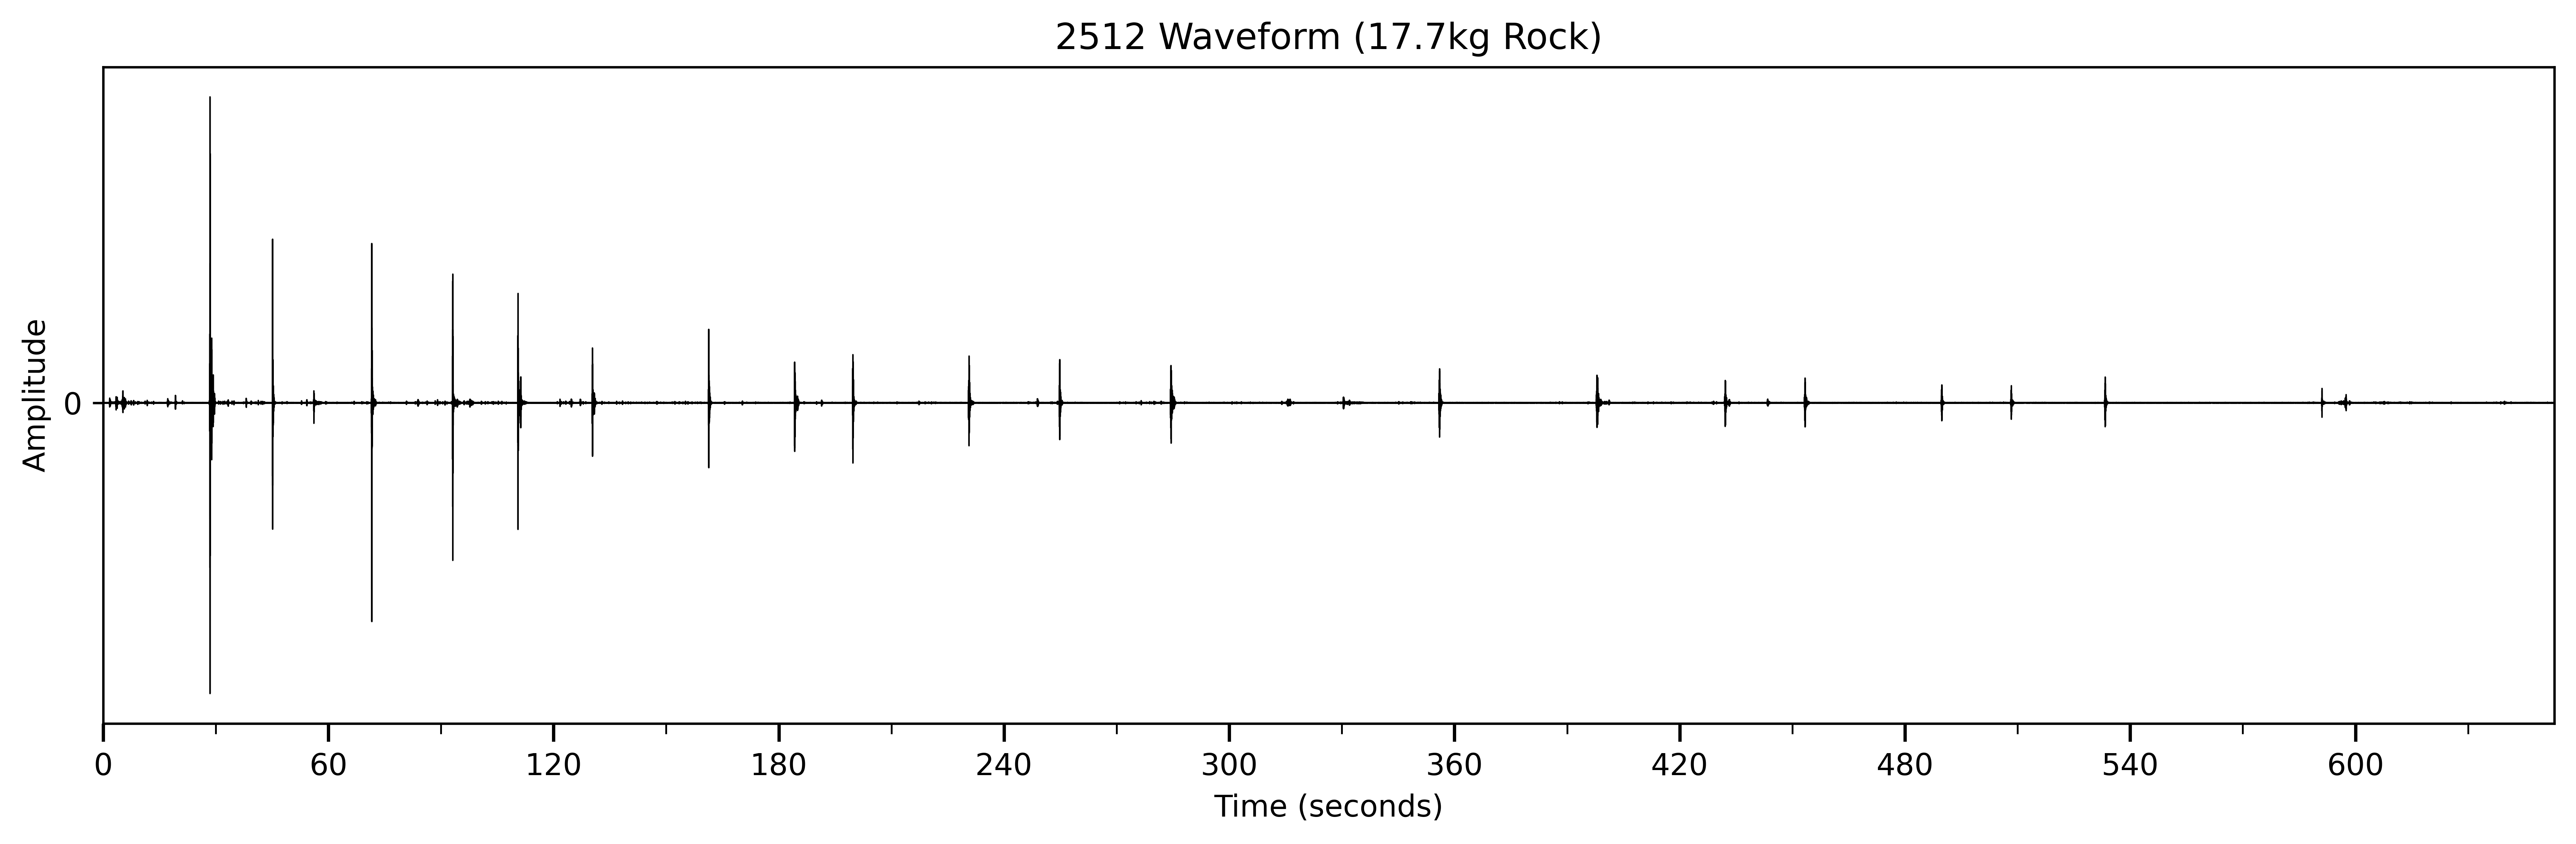

Computing and saving spectrogram...
Saving spectrogram to: C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\og_node\NO2512\full_spectra\2512_full_rock_spectra_2.png


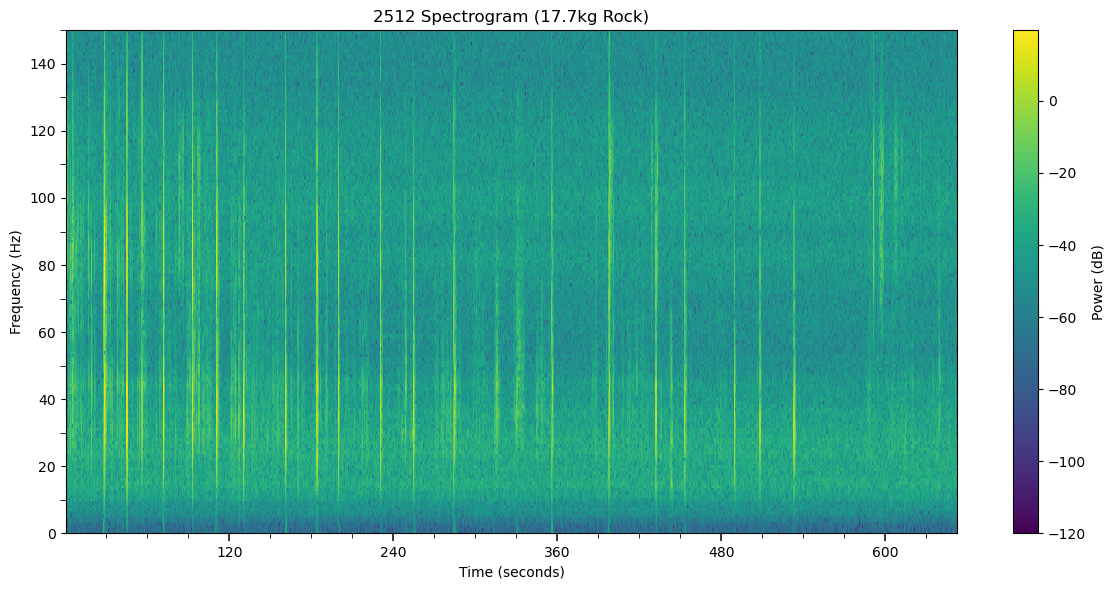

window length (ms): 1000, overlap (%): 500/1000 = 0.5


In [5]:
node_file = r"D:\2025_MSEED_From_Nodes\453005768.*.2025.10.2*.Z.miniseed" #N12

start_time = UTCDateTime(2025, 10, 24, 00, 19, 55) # N12 rock
end_time = UTCDateTime(2025, 10, 24, 00, 30, 48)

S = read(node_file)#, starttime=start_time, endtime=end_time)
print("Trace range:", S[0].stats.starttime, "→", S[0].stats.endtime)
print("File being read:", node_file)
print(S)

print("Traces loaded:", len(S))

# merge in case multiple files
S.merge(method=1)

#S.trim(starttime=start_time, endtime=end_time)
tr = S[0].slice(starttime=start_time, endtime=end_time)
#tr = S[0]

print(f"Sampling rate: {tr.stats.sampling_rate} Hz")
print(f"Number of samples: {len(tr.data)}")

# ----------------------------------------------------- raw waveform ----------------------------------------------------------

print("Plotting and saving raw waveform...")

time = np.linspace(0, len(tr.data)/tr.stats.sampling_rate, len(tr.data))

fig, ax = plt.subplots(figsize=(12,4), dpi=600)

ax.plot(time, tr.data, color='black', lw=0.5)

# ticks
ax.xaxis.set_major_locator(MultipleLocator(60)) # labled every 120s
ax.xaxis.set_minor_locator(MultipleLocator(30)) # unlabled every 30s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(500)) # labeled every 500
ax.set_xlim(np.min(time), np.max(time))
ax.set_title("2512 Waveform (17.7kg Rock)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
fig.tight_layout()

# define directory and png filename
plot_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\og_node\NO2512\full_wave"
plot_name = "2512_full_rock_wave_2.png"

# directory exists
os.makedirs(plot_dir, exist_ok=True)

# full path for saving png
save_path = os.path.join(plot_dir, plot_name)

# save plot as png with high resolution
print("Saving waveform to:", save_path)
plt.savefig(save_path, format='png', dpi=600, bbox_inches='tight')

# save as png
fig.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)

# ----------------------------------------------------- spectrogram -----------------------------------------------------------

print("Computing and saving spectrogram...")

fs = tr.stats.sampling_rate

# window sizes (SAFE starting values)
nperseg = int(1 * fs)     # 10 ms window
noverlap = int(0.5 * fs)   # 50% overlap
# freq_resolution = df = fs / nperseg = 1000/10 = 100 hz bins

f, t, Sxx = spectrogram(
    tr.data,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    #outfile=savepath
)

fig, ax = plt.subplots(figsize=(12,6))

pcm = ax.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), cmap='viridis')

# ticks
ax.xaxis.set_major_locator(MultipleLocator(120)) # tick label every 120s
ax.xaxis.set_minor_locator(MultipleLocator(30)) # tick unlabeled every 30s
ax.tick_params(axis='x', which='minor', length=3.5)
ax.tick_params(axis='x', which='major', length=6, width=1.1)
ax.yaxis.set_major_locator(MultipleLocator(20)) # tick label every 20 Hz
ax.yaxis.set_minor_locator(MultipleLocator(10)) # tick unlabeled every 10 Hz
ax.tick_params(axis='y', which='minor', length=4)

ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (seconds)')
ax.set_xlim(np.min(t), np.max(t))
ax.set_ylim(0, 150)
ax.set_title("2512 Spectrogram (17.7kg Rock)")
fig.colorbar(pcm, ax=ax, label='Power (dB)')
fig.tight_layout()

# define directory and png filename
spectra_dir = r"C:\Users\zzawol\OneDrive - DOI\Documents\MORA25\FluvialSeismology_Analysis\calib_testing\og_node\NO2512\full_spectra"
spectra_name = "2512_full_rock_spectra_2.png"

# directory exists
os.makedirs(spectra_dir, exist_ok=True)

# full path for saving png
savepath = os.path.join(spectra_dir, spectra_name)

# save as png
print("Saving spectrogram to:", savepath)
fig.savefig(savepath, dpi=600, bbox_inches='tight')

plt.show()
plt.close(fig)

print(f"window length (ms): {nperseg}, overlap (%): {noverlap}/{nperseg} = {noverlap/nperseg}")